### **Dataset** : Diabetes 130-US Hospitals for Years 1999–2008

### **Abou**t : It is a real-world healthcare dataset of 101,766 rows × 50 columns

In [1]:
!wget -O diabetes.zip "https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip"
!unzip diabetes.zip

--2026-07-09 17:41:46--  https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘diabetes.zip’

diabetes.zip            [  <=>               ]   3.02M  8.56MB/s    in 0.4s    

2026-07-09 17:41:47 (8.56 MB/s) - ‘diabetes.zip’ saved [3170254]

Archive:  diabetes.zip
  inflating: diabetic_data.csv       
  inflating: IDS_mapping.csv         


In [2]:
import os
print(os.listdir())

['.config', 'diabetic_data.csv', 'diabetes.zip', 'IDS_mapping.csv', 'sample_data']


### **Environment Setup and load the dataset**

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# **Basic Understanding regarding the dataset**

In [4]:
print(df.shape)

(101766, 50)


In [5]:
print(df.columns)

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [7]:
# Missing values
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [8]:
# Statistical summary
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [9]:
# Target variable distribution
print(df["readmitted"].value_counts())

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


### **Overview of the dataset**
RangeIndex : 101766 Rows, 0 to 101765

Total columns : 50

there are two data types:
a. int64 (13)
b. object (37)

Memory Usage : 38.8+ MB

## **Cleaning Notes**
1. **encounter_id** : Check missing values and convert data type to int64.
2. **patient_nbr**: Check missing values and convert data type to int64.
3. **race**: Replace "?" with NaN, fill missing values using Mode, then convert into numerical values.
4. **gender**: Remove "Unknown/Invalid" values and convert Male/Female into 1 and 0.
5. **age**: Convert age ranges ([0-10), [10-20), ...) into numeric age values.
6.** weight **: Most values are missing (?), so remove this column.
7. **admission_type_id **: Already numerical. Check for missing values.
8. **discharge_disposition_id** : Already numerical. Check for missing values.
9. **admission_source_id**: Already numerical. Check for missing values.
10. **time_in_hospital** : Check for invalid values and convert data type if required.
11. **payer_code** : Large number of missing values (?), remove this column.
12. **medical_specialty** : Replace "?" with NaN; if too many missing values, remove the column.
13. **num_lab_procedures** : Check for missing values and invalid values.
14. **num_procedures **: Check for missing values.
15. **num_medications** : Check for missing values.
16. **number_outpatient** : Check for missing values.
17. **number_emergency** : Check for missing values.
18.**number_inpatient**: Check for missing values.
19. **diag_1** : Replace "?" with "Unknown" and handle missing values.
20. **diag_2**: Replace "?" with "Unknown" and handle missing values.
21. **diag_3** : Replace "?" with "Unknown" and handle missing values.
22. **max_glu_serum** : Convert categorical values into numerical values.
23. **A1Cresult**: Convert categorical values into numerical values.
24. Medication Columns (metformin, repaglinide, nateglinide, ..., insulin) : Convert No, Steady, Up, and Down into numerical values.
25. **change** : Convert No and Ch into numerical values.
26. **bdiabetesMed** : Convert No and Yes into numerical values.
27. **readmitted**: Convert target values (NO, >30, <30) into numerical labels (0, 1, 2).
28. **Final Check** : Verify missing values, duplicate rows, and data types before saving the cleaned dataset.

# **DATA CLEANING**:

# **1. encounter_id**

### Checked datatype

In [10]:
df["encounter_id"].dtype

dtype('int64')

### Check missing values

In [11]:
df["encounter_id"].isnull().sum()

np.int64(0)

### Convert datatype

In [12]:
df["encounter_id"] = df["encounter_id"].astype("int64")

# **2. patient_nbr**

### Checked missing values

In [13]:
df["patient_nbr"].isnull().sum()

np.int64(0)

### Step 2 : Convert datatype

In [14]:
df["patient_nbr"] = df["patient_nbr"].astype("int64")

# **3. race**

### Check unique values

In [15]:
df["race"].unique()

array(['Caucasian', 'AfricanAmerican', '?', 'Other', 'Asian', 'Hispanic'],
      dtype=object)

### Check null values

In [16]:
df["race"].isnull().sum()

np.int64(0)

### Replace missing values with Mode

In [17]:
import numpy as np

df["race"] = df["race"].replace("?", np.nan)

mode_race = df["race"].mode()[0]

df["race"] = df["race"].fillna(mode_race)

### Convert categorical into numerical

In [18]:
race_map = {
    "Caucasian":1,
    "AfricanAmerican":2,
    "Asian":3,
    "Hispanic":4,
    "Other":5
}

df["race"] = df["race"].map(race_map)

# **4. gender**

### Check unique values

In [19]:
df["gender"].unique()

array(['Female', 'Male', 'Unknown/Invalid'], dtype=object)

### Remove invalid value

In [20]:
df = df[df["gender"] != "Unknown/Invalid"]

### Convert into numerical

In [21]:
gender_map = {
    "Male":1,
    "Female":0
}

df["gender"] = df["gender"].map(gender_map)

# **5. age**

### Check unique values

In [22]:
df["age"].unique()

array(['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)',
       '[60-70)', '[70-80)', '[80-90)', '[90-100)'], dtype=object)

### Convert age groups into numbers

In [23]:
age_map = {
    "[0-10)":5,
    "[10-20)":15,
    "[20-30)":25,
    "[30-40)":35,
    "[40-50)":45,
    "[50-60)":55,
    "[60-70)":65,
    "[70-80)":75,
    "[80-90)":85,
    "[90-100)":95
}

df["age"] = df["age"].map(age_map)

# **6. admission_type_id**

Already numeric

In [24]:
df["admission_type_id"].dtype

dtype('int64')

# **7. discharge_disposition_id**

Already numeric

In [25]:
df["discharge_disposition_id"].dtype

dtype('int64')

# **8. admission_source_id**

Already numeric

In [26]:
df["admission_source_id"].dtype

dtype('int64')

# **9. diagnosis columns (diag_1, diag_2, diag_3)**

### Replace missing values

In [27]:
df["diag_1"] = df["diag_1"].replace("?", np.nan)
df["diag_1"] = df["diag_1"].fillna("Unknown")

In [28]:
df["diag_2"] = df["diag_2"].replace("?", np.nan)
df["diag_2"] = df["diag_2"].fillna("Unknown")

In [29]:
df["diag_3"] = df["diag_3"].replace("?", np.nan)
df["diag_3"] = df["diag_3"].fillna("Unknown")

# **10. Binary columns**

In [30]:
binary_map = {
    "No":0,
    "Yes":1
}

df["change"] = df["change"].map(binary_map)

df["diabetesMed"] = df["diabetesMed"].map(binary_map)

# **11. Target Column**

In [31]:
df["readmitted"].unique()

array(['NO', '>30', '<30'], dtype=object)

### Convert into numbers

In [32]:
target_map = {
    "NO":0,
    ">30":1,
    "<30":2
}

df["readmitted"] = df["readmitted"].map(target_map)


These cells are added at the end so the old code remains unchanged.  
Purpose: complete remaining cleaning, fix the binary mapping issue, optimize memory, create a cleaning log, validate the final dataset, and save the cleaned dataset.

## **12. Final setup for cleaning log and before/after comparison**
This section stores the dataset size and memory before final fixes, so we can clearly show what changed.

In [33]:
import os
import numpy as np
import pandas as pd

# Copy df before final teacher fixes for comparison
rows_before_final, cols_before_final = df.shape
memory_before_final_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

cleaning_log = []

def add_log(step, column, action, reason, rows_before=None, rows_after=None):
    """Store every important cleaning step in a simple point-wise log."""
    cleaning_log.append({
        "Step": step,
        "Column": column,
        "Action Taken": action,
        "Why This Was Needed": reason,
        "Rows Before": rows_before,
        "Rows After": rows_after
    })

print("Shape before final fixes:", df.shape)
print("Memory before final fixes:", round(memory_before_final_mb, 2), "MB")

Shape before final fixes: (101763, 50)
Memory before final fixes: 166.95 MB


## **13. Standardize missing values**
In this dataset, missing values are not only stored as `NaN`; many columns also use `?`.  
So, all `?` values are converted into proper missing values first.

In [34]:
# Convert dataset-specific missing symbol '?' into real NaN values
missing_question_before = (df == "?").sum().sum()
df = df.replace("?", np.nan)

add_log(
    step="Missing Value Standardization",
    column="All columns",
    action="Replaced '?' with NaN",
    reason="The raw dataset uses '?' to represent missing values. Pandas does not treat '?' as null automatically.",
    rows_before=rows_before_final,
    rows_after=df.shape[0]
)

print("Total '?' values replaced:", int(missing_question_before))

Total '?' values replaced: 188768


## **14. Drop high-missing columns**
`weight`, `payer_code`, and `medical_specialty` contain too many missing values or are not reliable for clean analysis.  
Dropping them makes the cleaned dataset more useful and avoids misleading results.

In [35]:
# Check missing percentage before dropping columns
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)
print("Top missing-value columns before dropping:")
print(missing_percent.head(10))

high_missing_cols = [col for col in ["weight", "payer_code", "medical_specialty"] if col in df.columns]

if high_missing_cols:
    cols_before = df.shape[1]
    df = df.drop(columns=high_missing_cols)
    add_log(
        step="High Missing Columns",
        column=", ".join(high_missing_cols),
        action="Dropped columns",
        reason="These columns have very high missing values and can reduce data quality.",
        rows_before=rows_before_final,
        rows_after=df.shape[0]
    )
    print("Dropped columns:", high_missing_cols)
    print("Columns before:", cols_before, "| Columns after:", df.shape[1])
else:
    print("No selected high-missing columns found to drop.")

Top missing-value columns before dropping:
weight               96.858387
max_glu_serum        94.746617
A1Cresult            83.276829
medical_specialty    49.081690
change               46.194589
payer_code           39.557600
admission_type_id     0.000000
encounter_id          0.000000
patient_nbr           0.000000
race                  0.000000
dtype: float64
Dropped columns: ['weight', 'payer_code', 'medical_specialty']
Columns before: 50 | Columns after: 47


## **15. Fix binary column mapping**
Earlier, `change` was mapped using `Yes/No`, but the diabetes dataset uses `Ch/No`.  
This cell fixes it by taking the original values from `diabetic_data.csv` using `encounter_id`, then mapping correctly:
- `No` → 0
- `Ch` → 1

In [36]:
# Correct binary mapping for change and diabetesMed using the raw CSV as reference
# This keeps earlier code unchanged and fixes the issue at the end.
if os.path.exists("diabetic_data.csv") and "encounter_id" in df.columns:
    raw_binary = pd.read_csv(
        "diabetic_data.csv",
        usecols=["encounter_id", "change", "diabetesMed"]
    )
    raw_binary = raw_binary.set_index("encounter_id")

    if "change" in df.columns:
        df["change"] = df["encounter_id"].map(raw_binary["change"]).map({"No": 0, "Ch": 1})
        add_log(
            step="Binary Mapping Fix",
            column="change",
            action="Mapped No=0 and Ch=1",
            reason="The original dataset uses 'Ch', not 'Yes', so the earlier mapping created missing values.",
            rows_before=rows_before_final,
            rows_after=df.shape[0]
        )

    if "diabetesMed" in df.columns:
        df["diabetesMed"] = df["encounter_id"].map(raw_binary["diabetesMed"]).map({"No": 0, "Yes": 1})
        add_log(
            step="Binary Mapping Check",
            column="diabetesMed",
            action="Mapped No=0 and Yes=1",
            reason="Converted binary text values into numeric form for analysis/modeling.",
            rows_before=rows_before_final,
            rows_after=df.shape[0]
        )
else:
    print("Raw CSV not found, so binary columns were not reloaded from source.")

print("Missing in change:", df["change"].isna().sum() if "change" in df.columns else "Column not found")
print("Missing in diabetesMed:", df["diabetesMed"].isna().sum() if "diabetesMed" in df.columns else "Column not found")

Missing in change: 0
Missing in diabetesMed: 0


## **16. Encode remaining categorical medical columns**
The medicine columns contain text values like `No`, `Steady`, `Up`, and `Down`.  
These are converted into numbers so the cleaned dataset is ready for analysis and machine learning.

In [37]:
medicine_cols = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "examide", "citoglipton", "insulin", "glyburide-metformin",
    "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone",
    "metformin-pioglitazone"
]
medicine_cols = [col for col in medicine_cols if col in df.columns]
medicine_map = {"No": 0, "Steady": 1, "Up": 2, "Down": 3}

for col in medicine_cols:
    if df[col].dtype == "object" or str(df[col].dtype) == "category":
        df[col] = df[col].map(medicine_map)

add_log(
    step="Categorical Encoding",
    column=", ".join(medicine_cols),
    action="Mapped No=0, Steady=1, Up=2, Down=3",
    reason="Medicine status columns are categorical and need numeric format for analysis/modeling.",
    rows_before=rows_before_final,
    rows_after=df.shape[0]
)

print("Encoded medicine columns:", len(medicine_cols))

Encoded medicine columns: 23


## **17. Encode lab result columns**
`max_glu_serum` and `A1Cresult` are ordered categories, so they are converted into numeric levels.

In [38]:
if "max_glu_serum" in df.columns:
    df["max_glu_serum"] = df["max_glu_serum"].map({"None": 0, "Norm": 1, ">200": 2, ">300": 3})
    add_log(
        step="Lab Result Encoding",
        column="max_glu_serum",
        action="Mapped None=0, Norm=1, >200=2, >300=3",
        reason="Converted ordered lab result categories into numeric form.",
        rows_before=rows_before_final,
        rows_after=df.shape[0]
    )

if "A1Cresult" in df.columns:
    df["A1Cresult"] = df["A1Cresult"].map({"None": 0, "Norm": 1, ">7": 2, ">8": 3})
    add_log(
        step="Lab Result Encoding",
        column="A1Cresult",
        action="Mapped None=0, Norm=1, >7=2, >8=3",
        reason="Converted ordered lab result categories into numeric form.",
        rows_before=rows_before_final,
        rows_after=df.shape[0]
    )

print(df[[col for col in ["max_glu_serum", "A1Cresult"] if col in df.columns]].head())

   max_glu_serum  A1Cresult
0            NaN        NaN
1            NaN        NaN
2            NaN        NaN
3            NaN        NaN
4            NaN        NaN


## **18. Remove duplicate records**
`encounter_id` should be unique because it represents one hospital encounter.  
Duplicate encounters can disturb analysis, so they are removed if present.

In [39]:
rows_before = df.shape[0]

if "encounter_id" in df.columns:
    df = df.drop_duplicates(subset=["encounter_id"])
else:
    df = df.drop_duplicates()

rows_after = df.shape[0]

add_log(
    step="Duplicate Removal",
    column="encounter_id" if "encounter_id" in df.columns else "All columns",
    action=f"Removed {rows_before - rows_after} duplicate rows",
    reason="Duplicate records can create biased analysis and repeated patient encounters.",
    rows_before=rows_before,
    rows_after=rows_after
)

print("Duplicate rows removed:", rows_before - rows_after)
print("Shape after duplicate removal:", df.shape)

Duplicate rows removed: 0
Shape after duplicate removal: (101763, 47)


## **19. Validate numeric ranges**
This checks important numeric columns and removes impossible values if found.

In [40]:
range_rules = {
    "time_in_hospital": (1, 14),
    "num_lab_procedures": (0, None),
    "num_procedures": (0, None),
    "num_medications": (0, None),
    "number_outpatient": (0, None),
    "number_emergency": (0, None),
    "number_inpatient": (0, None),
    "number_diagnoses": (0, None),
}

for col, (min_value, max_value) in range_rules.items():
    if col in df.columns:
        before = df.shape[0]
        condition = df[col] >= min_value
        if max_value is not None:
            condition = condition & (df[col] <= max_value)
        df = df[condition]
        after = df.shape[0]

        add_log(
            step="Range Validation",
            column=col,
            action=f"Removed {before - after} invalid rows",
            reason=f"Kept only valid values for {col}.",
            rows_before=before,
            rows_after=after
        )

print("Shape after numeric range validation:", df.shape)

Shape after numeric range validation: (101763, 47)


## **20. Final missing-value check**
After cleaning, this cell checks if any missing values are still present.

In [41]:
missing_after_cleaning = df.isna().sum().sort_values(ascending=False)
missing_after_cleaning = missing_after_cleaning[missing_after_cleaning > 0]

if len(missing_after_cleaning) == 0:
    print("No missing values left in the cleaned dataset.")
else:
    print("Columns still having missing values:")
    print(missing_after_cleaning)

Columns still having missing values:
max_glu_serum    96417
A1Cresult        84745
dtype: int64


## **21. Data type and memory optimization**
This reduces memory usage by downcasting numeric columns and converting suitable object columns into category type.

In [42]:
memory_before_optimization_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

# Downcast integer and float columns
for col in df.select_dtypes(include=["int64", "int32", "float64", "float32"]).columns:
    # If a numeric column has no missing values and all values are whole numbers, store it as integer.
    if df[col].isna().sum() == 0 and np.all(np.equal(np.mod(df[col], 1), 0)):
        df[col] = pd.to_numeric(df[col], downcast="integer")
    else:
        df[col] = pd.to_numeric(df[col], downcast="float")

# Convert low-cardinality text columns to category to reduce memory
for col in df.select_dtypes(include=["object"]).columns:
    unique_ratio = df[col].nunique(dropna=False) / len(df)
    if unique_ratio < 0.50:
        df[col] = df[col].astype("category")

memory_after_optimization_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

add_log(
    step="Memory Optimization",
    column="All possible columns",
    action="Downcasted numeric columns and converted low-cardinality object columns to category",
    reason="Reduced dataset memory usage without changing the meaning of the data.",
    rows_before=df.shape[0],
    rows_after=df.shape[0]
)

print("Memory before optimization:", round(memory_before_optimization_mb, 2), "MB")
print("Memory after optimization:", round(memory_after_optimization_mb, 2), "MB")
print("Memory reduced by:", round(memory_before_optimization_mb - memory_after_optimization_mb, 2), "MB")

Memory before optimization: 50.13 MB
Memory after optimization: 7.07 MB
Memory reduced by: 43.07 MB


## **22. Final validation summary**
This gives a clear before/after report for teacher review.

In [43]:
final_summary = pd.DataFrame({
    "Metric": [
        "Rows before final fixes",
        "Rows after final fixes",
        "Columns before final fixes",
        "Columns after final fixes",
        "Missing values left",
        "Memory before final fixes (MB)",
        "Memory after final fixes (MB)"
    ],
    "Value": [
        rows_before_final,
        df.shape[0],
        cols_before_final,
        df.shape[1],
        int(df.isna().sum().sum()),
        round(memory_before_final_mb, 2),
        round(df.memory_usage(deep=True).sum() / (1024 ** 2), 2)
    ]
})

final_summary

,Metric,Value
0,Rows before final fixes,101763.00
1,Rows after final fixes,101763.00
2,Columns before final fixes,50.00
3,Columns after final fixes,47.00
4,Missing values left,181162.00
5,Memory before final fixes (MB),166.95
6,Memory after final fixes (MB),7.07


## **23. Point-wise cleaning log**
This is the clean explanation of what was done and why it was done.

In [44]:
cleaning_log_df = pd.DataFrame(cleaning_log)
cleaning_log_df

,Step,Column,Action Taken,Why This Was Needed,Rows Before,Rows After
0,Missing Value Standardization,All columns,Replaced '?' with NaN,The raw dataset uses '?' to represent missing ...,101763,101763
1,High Missing Columns,"weight, payer_code, medical_specialty",Dropped columns,These columns have very high missing values an...,101763,101763
2,Binary Mapping Fix,change,Mapped No=0 and Ch=1,"The original dataset uses 'Ch', not 'Yes', so ...",101763,101763
3,Binary Mapping Check,diabetesMed,Mapped No=0 and Yes=1,Converted binary text values into numeric form...,101763,101763
4,Categorical Encoding,"metformin, repaglinide, nateglinide, chlorprop...","Mapped No=0, Steady=1, Up=2, Down=3",Medicine status columns are categorical and ne...,101763,101763
5,Lab Result Encoding,max_glu_serum,"Mapped None=0, Norm=1, >200=2, >300=3",Converted ordered lab result categories into n...,101763,101763
6,Lab Result Encoding,A1Cresult,"Mapped None=0, Norm=1, >7=2, >8=3",Converted ordered lab result categories into n...,101763,101763
7,Duplicate Removal,encounter_id,Removed 0 duplicate rows,Duplicate records can create biased analysis a...,101763,101763
8,Range Validation,time_in_hospital,Removed 0 invalid rows,Kept only valid values for time_in_hospital.,101763,101763
9,Range Validation,num_lab_procedures,Removed 0 invalid rows,Kept only valid values for num_lab_procedures.,101763,101763


## **24. Save cleaned dataset and cleaning logs**
The cleaned dataset is saved inside a folder named `Cleaned_Dataset`.

In [45]:
output_dir = "Cleaned_Dataset"
os.makedirs(output_dir, exist_ok=True)

clean_csv_path = os.path.join(output_dir, "diabetes_cleaned_dataset.csv")
log_csv_path = os.path.join(output_dir, "diabetes_cleaning_log.csv")
summary_csv_path = os.path.join(output_dir, "diabetes_final_summary.csv")

# Save cleaned dataset and logs as CSV
df.to_csv(clean_csv_path, index=False)
cleaning_log_df.to_csv(log_csv_path, index=False)
final_summary.to_csv(summary_csv_path, index=False)

# Save parquet also if the required engine is available
parquet_path = os.path.join(output_dir, "diabetes_cleaned_dataset.parquet")
try:
    df.to_parquet(parquet_path, index=False)
    print("Parquet file saved:", parquet_path)
except Exception as e:
    print("Parquet file not saved because parquet engine is not available:", e)

print("Cleaned CSV saved:", clean_csv_path)
print("Cleaning log saved:", log_csv_path)
print("Final summary saved:", summary_csv_path)
print("Final shape:", df.shape)

Parquet file saved: Cleaned_Dataset/diabetes_cleaned_dataset.parquet
Cleaned CSV saved: Cleaned_Dataset/diabetes_cleaned_dataset.csv
Cleaning log saved: Cleaned_Dataset/diabetes_cleaning_log.csv
Final summary saved: Cleaned_Dataset/diabetes_final_summary.csv
Final shape: (101763, 47)


## **25. Final cleaned dataset preview**

In [46]:
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,1,0,5,6,25,1,1,41,...,0,0,0,0,0,0,0,0,0,0
1,149190,55629189,1,0,15,1,1,7,3,59,...,0,2,0,0,0,0,0,1,1,1
2,64410,86047875,2,0,25,1,1,7,2,11,...,0,0,0,0,0,0,0,0,1,0
3,500364,82442376,1,1,35,1,1,7,2,44,...,0,2,0,0,0,0,0,1,1,0
4,16680,42519267,1,1,45,1,1,7,1,51,...,0,1,0,0,0,0,0,1,1,0


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101763 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   encounter_id              101763 non-null  int32   
 1   patient_nbr               101763 non-null  int32   
 2   race                      101763 non-null  int8    
 3   gender                    101763 non-null  int8    
 4   age                       101763 non-null  int8    
 5   admission_type_id         101763 non-null  int8    
 6   discharge_disposition_id  101763 non-null  int8    
 7   admission_source_id       101763 non-null  int8    
 8   time_in_hospital          101763 non-null  int8    
 9   num_lab_procedures        101763 non-null  int16   
 10  num_procedures            101763 non-null  int8    
 11  num_medications           101763 non-null  int8    
 12  number_outpatient         101763 non-null  int8    
 13  number_emergency          101763 n

# **Final Note**
The notebook now contains:
- complete missing-value handling,
- high-missing column removal,
- fixed binary mapping for `change`,
- categorical encoding,
- duplicate removal,
- range validation,
- memory optimization,
- point-wise cleaning logs,
- and code to save the cleaned dataset.

# **Stastical Analysis** - Done by Khyati Batra

**Target Variable: Readmission Status**
Since the ultimate question behind this dataset is which encounters lead to readmission, we begin by examining the balance of the target variable, readmitted. This shapes how later comparisons and tests should be interpreted.

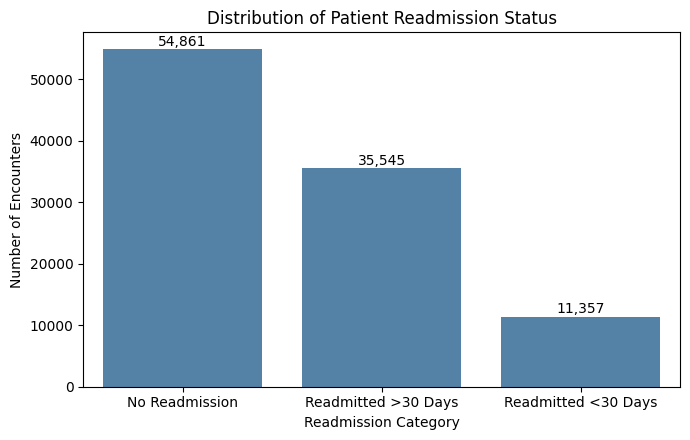

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

readmit_labels = {
    0: "No Readmission",
    1: "Readmitted >30 Days",
    2: "Readmitted <30 Days"
}

readmit_counts = df["readmitted"].map(readmit_labels).value_counts()

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=readmit_counts.index, y=readmit_counts.values, ax=ax, color="steelblue")
ax.set_title("Distribution of Patient Readmission Status")
ax.set_xlabel("Readmission Category")
ax.set_ylabel("Number of Encounters")
for i, v in enumerate(readmit_counts.values):
    ax.text(i, v + (0.01 * readmit_counts.values.max()), f"{v:,}", ha="center")
plt.tight_layout()
plt.show()

**Observation**: The classes are imbalanced — encounters with no readmission dominate, while readmission within 30 days is the smallest group. This imbalance is kept in mind when interpreting group comparisons later, since small subgroups produce noisier statistics

# **1. Univariate Analysis**

1.1 Numerical Variables
We examine the distribution shape of the core numeric variables — patient age and hospital utilization counts — to understand typical ranges, spread, and skewness before relating them to other variables.

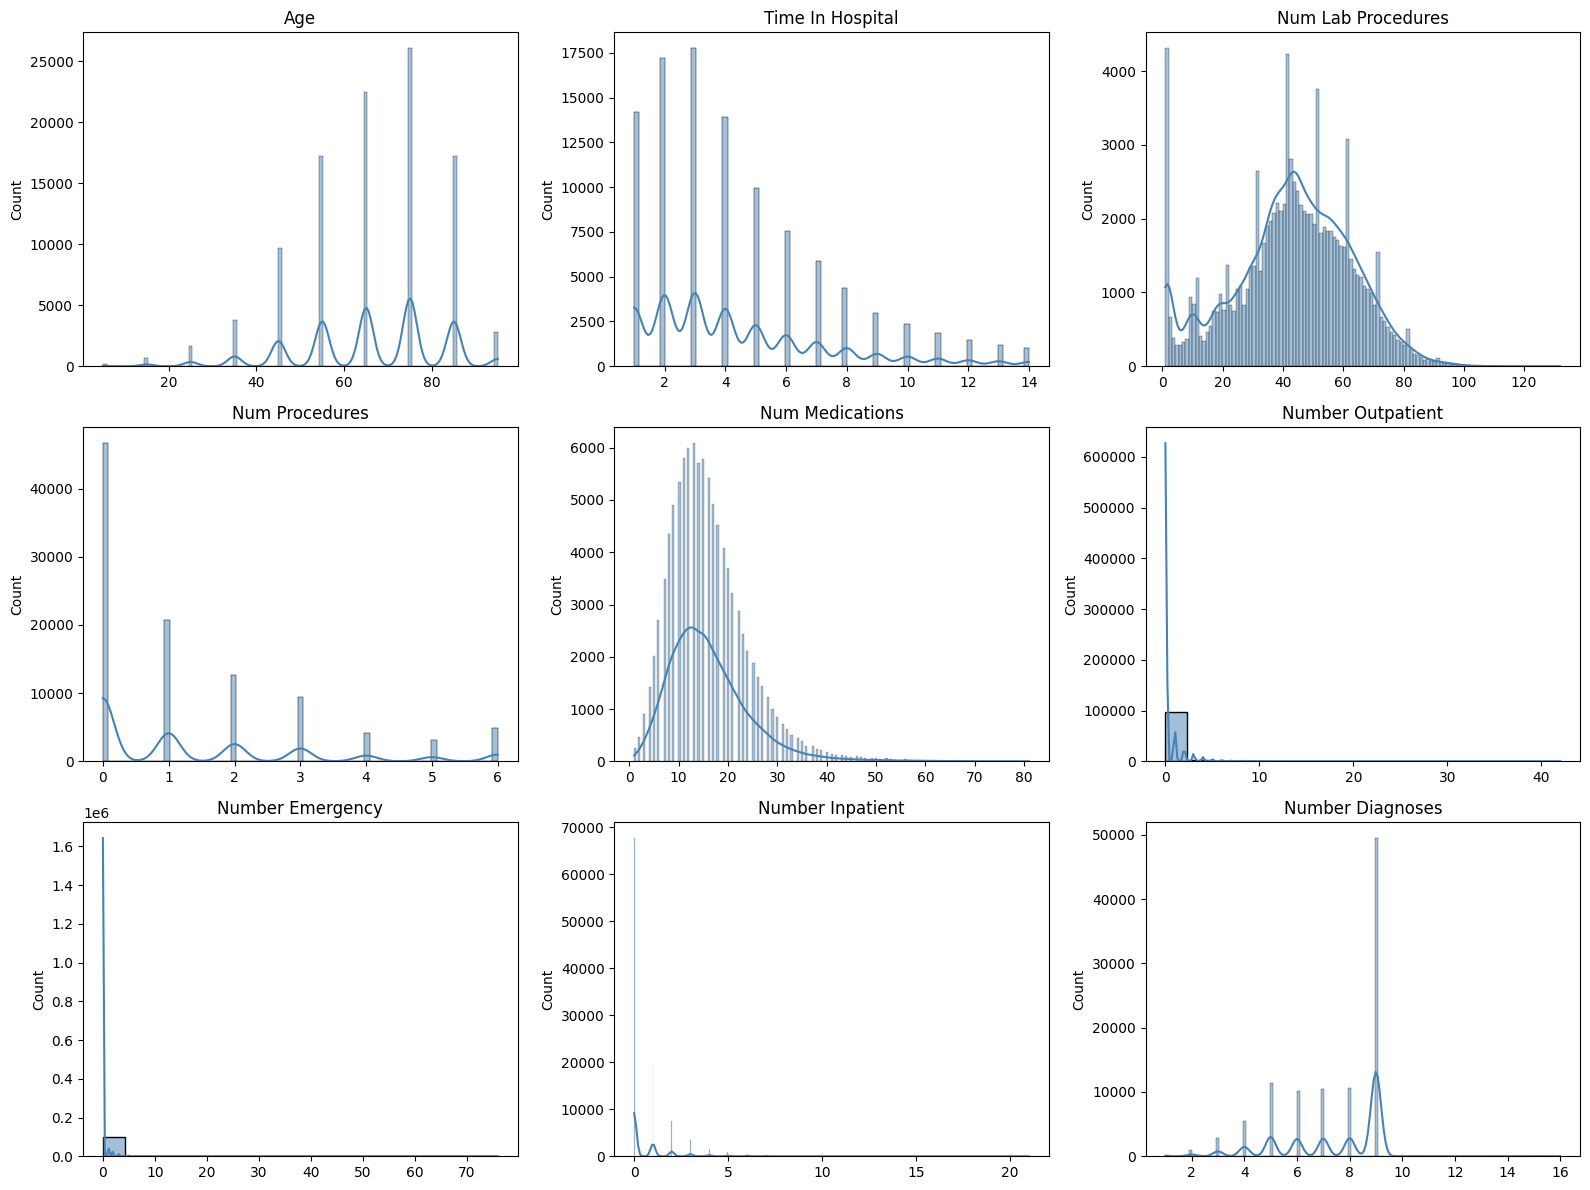

In [50]:
numeric_cols = ["age", "time_in_hospital", "num_lab_procedures", "num_procedures",
                "num_medications", "number_outpatient", "number_emergency",
                "number_inpatient", "number_diagnoses"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(col.replace("_", " ").title())
    axes[i].set_xlabel("")
plt.tight_layout()
plt.show()

A skewness score for each numeric variable quantifies what the histograms above suggest visually, and flags which columns are most asymmetric.


In [51]:
skew_table = df[numeric_cols].skew().sort_values(ascending=False)
skew_table

,0
number_emergency,22.855272
number_outpatient,8.832837
number_inpatient,3.614085
num_medications,1.326716
num_procedures,1.316460
time_in_hospital,1.134030
num_lab_procedures,-0.236531
age,-0.630507
number_diagnoses,-0.876799


**Observation**: number_emergency, number_outpatient, and number_inpatient are heavily right-skewed — most encounters have zero prior visits of these types, with a long tail of patients who visit frequently. age (built from midpoints of 10-year bins) is left-skewed, reflecting a hospital population weighted toward older patients. time_in_hospital and num_lab_procedures are close to symmetric.

# **1.2Categorical Variables**
Next, we look at the frequency distribution of key categorical and ordinal fields — demographic attributes, lab-test results, and medication status — to understand the composition of the patient population.

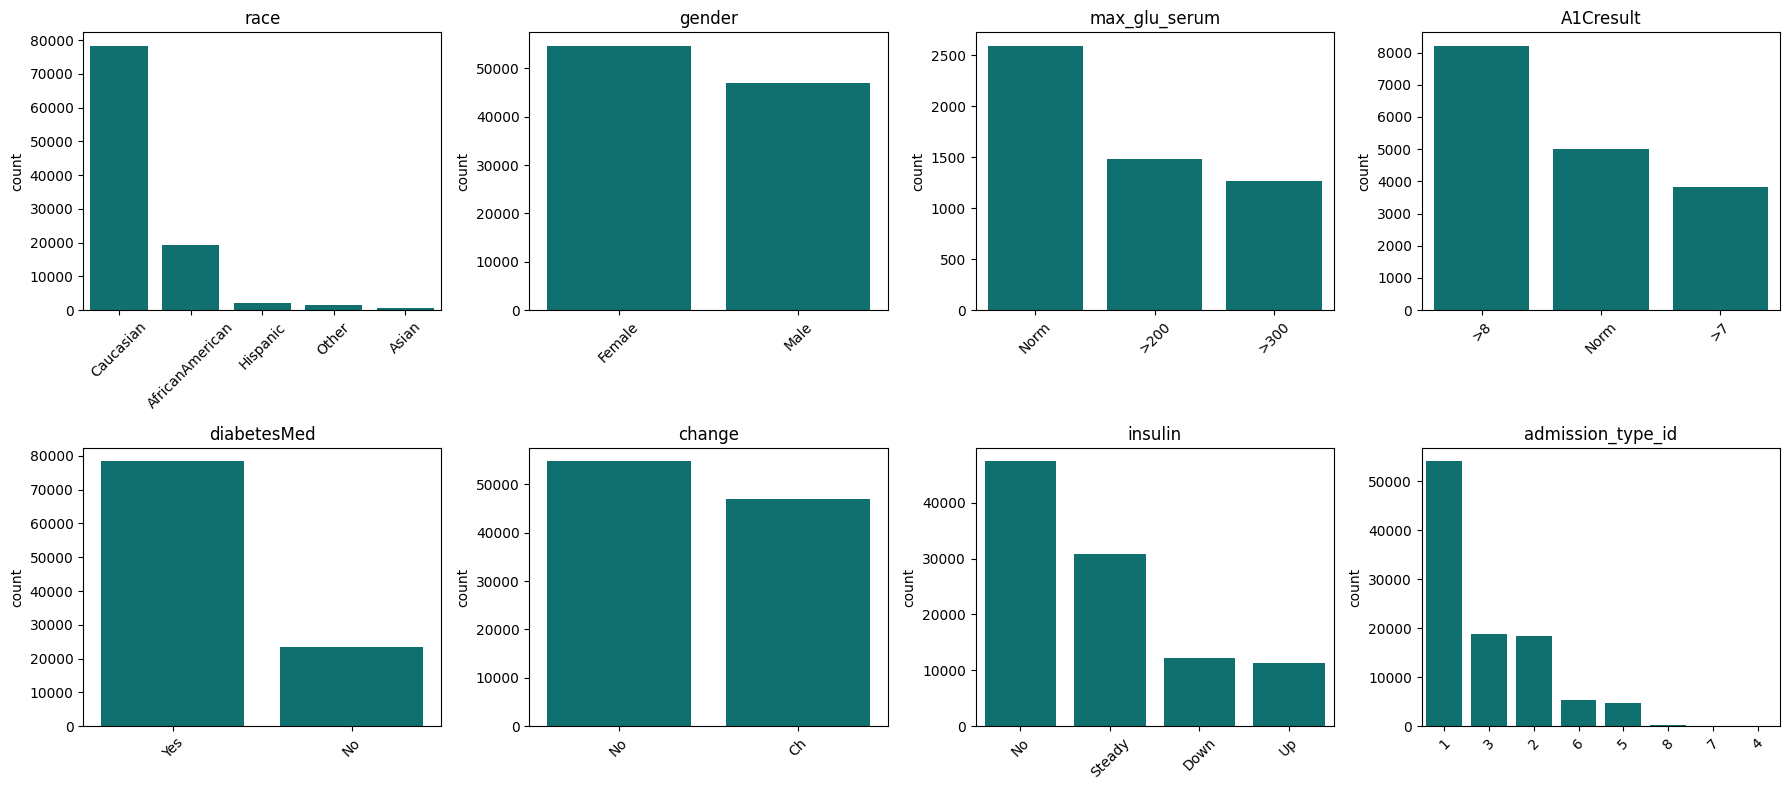

In [53]:
race_labels = {
    1: "Caucasian",
    2: "AfricanAmerican",
    3: "Asian",
    4: "Hispanic",
    5: "Other"
}

gender_labels = {
    1: "Male",
    0: "Female"
}

glu_labels = {
    0: "None",
    1: "Norm",
    2: ">200",
    3: ">300"
}

a1c_labels = {
    0: "None",
    1: "Norm",
    2: ">7",
    3: ">8"
}

yes_no_labels = {
    0: "No",
    1: "Yes"
}

change_labels = {
    0: "No",
    1: "Ch"
}

med_status_labels = {
    0: "No",
    1: "Steady",
    2: "Up",
    3: "Down"
}

categorical_specs = [
    ("race", race_labels), ("gender", gender_labels),
    ("max_glu_serum", glu_labels), ("A1Cresult", a1c_labels),
    ("diabetesMed", yes_no_labels), ("change", change_labels),
    ("insulin", med_status_labels), ("admission_type_id", None),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, (col, labels) in enumerate(categorical_specs):
    series = df[col].map(labels) if labels else df[col].astype(str)
    order = series.value_counts().index
    sns.countplot(x=series, order=order, ax=axes[i], color="teal")
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].set_xlabel("")
plt.tight_layout()
plt.show()

**Observation**: The patient population is predominantly Caucasian, close to evenly split by gender, and for most encounters glucose serum and A1C tests were not taken (None), which is consistent with these being routine rather than universally ordered labs. Most medication statuses show No as the dominant category, meaning the drug was not prescribed during that encounter, while insulin is one of the more actively adjusted medications.

# **2. Bivariate Analysis**

**2.1 Age vs. Readmission**
We compare the age distribution across readmission categories to see whether older patients are more likely to be readmitted.

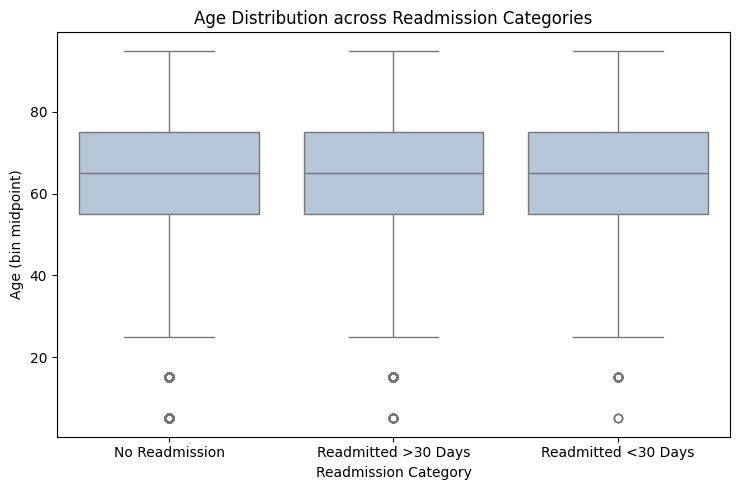

In [54]:
fig, ax = plt.subplots(figsize=(7.5, 5))
sns.boxplot(x=df["readmitted"].map(readmit_labels), y=df["age"], ax=ax, color="lightsteelblue")
ax.set_title("Age Distribution across Readmission Categories")
ax.set_xlabel("Readmission Category")
ax.set_ylabel("Age (bin midpoint)")
plt.tight_layout()
plt.show()

6.2 **Gender vs. Readmission**



A proportional breakdown of readmission status within each gender indicates whether gender is associated with a different chance of readmission.

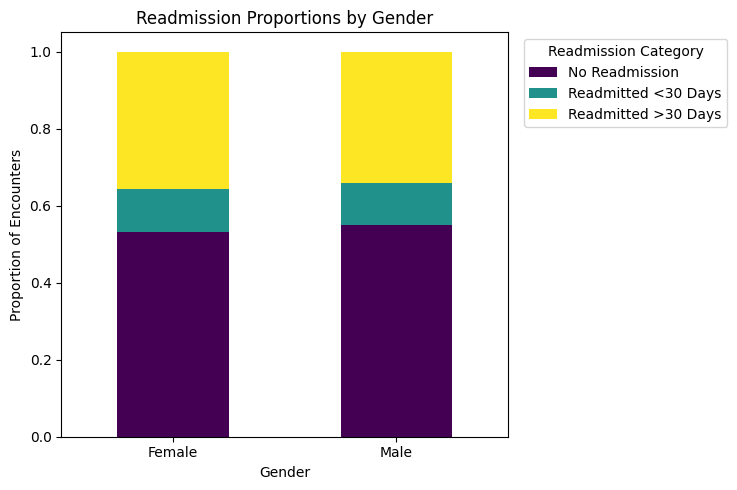

In [55]:
gender_readmit = pd.crosstab(df["gender"].map(gender_labels), df["readmitted"].map(readmit_labels), normalize="index")

gender_readmit.plot(kind="bar", stacked=True, figsize=(7.5, 5), colormap="viridis")
plt.title("Readmission Proportions by Gender")
plt.xlabel("Gender")
plt.ylabel("Proportion of Encounters")
plt.xticks(rotation=0)
plt.legend(title="Readmission Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# **2.3 Length of Stay vs. Readmission**
We compare time_in_hospital across readmission groups, since longer admissions could reflect more complex cases that are also more likely to return.


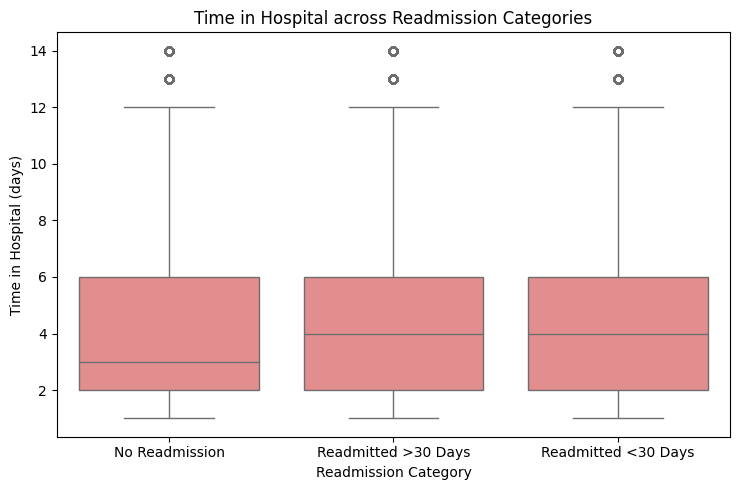

In [56]:
fig, ax = plt.subplots(figsize=(7.5, 5))
sns.boxplot(x=df["readmitted"].map(readmit_labels), y=df["time_in_hospital"], ax=ax, color="lightcoral")
ax.set_title("Time in Hospital across Readmission Categories")
ax.set_xlabel("Readmission Category")
ax.set_ylabel("Time in Hospital (days)")
plt.tight_layout()
plt.show()

# **2.4 Race vs. Readmission Rate**
A row-normalized crosstab shows the readmission profile within each racial group, useful for spotting any subgroup with a noticeably different pattern.

In [57]:
race_readmit = pd.crosstab(df["race"].map(race_labels), df["readmitted"].map(readmit_labels), normalize="index")
race_readmit.style.format("{:.1%}").background_gradient(cmap="Reds", axis=1)

readmitted,No Readmission,Readmitted <30 Days,Readmitted >30 Days
race,,,
AfricanAmerican,54.2%,11.2%,34.5%
Asian,64.7%,10.1%,25.1%
Caucasian,53.5%,11.2%,35.3%
Hispanic,58.1%,10.4%,31.5%
Other,60.7%,9.6%,29.6%


# **2.5 Diabetes Medication vs. Readmission**
Since diabetesMed indicates whether the patient was on diabetes medication at all, comparing readmission proportions by this flag tests whether medicated patients are managed differently in terms of return visits.

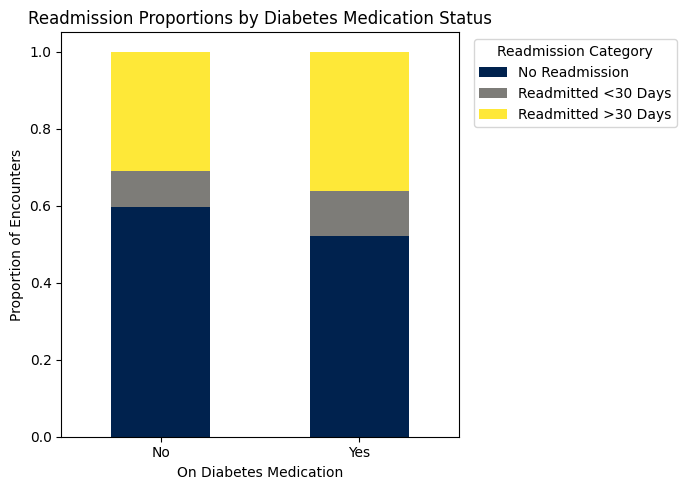

In [58]:
med_readmit = pd.crosstab(df["diabetesMed"].map(yes_no_labels), df["readmitted"].map(readmit_labels), normalize="index")

med_readmit.plot(kind="bar", stacked=True, figsize=(7, 5), colormap="cividis")
plt.title("Readmission Proportions by Diabetes Medication Status")
plt.xlabel("On Diabetes Medication")
plt.ylabel("Proportion of Encounters")
plt.xticks(rotation=0)
plt.legend(title="Readmission Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# **6.6 Medications vs. Lab Procedures**
A scatter of `num_medications` against `num_lab_procedures`, colored by readmission status, checks whether encounters with heavier medication and testing loads cluster into a particular readmission outcome.

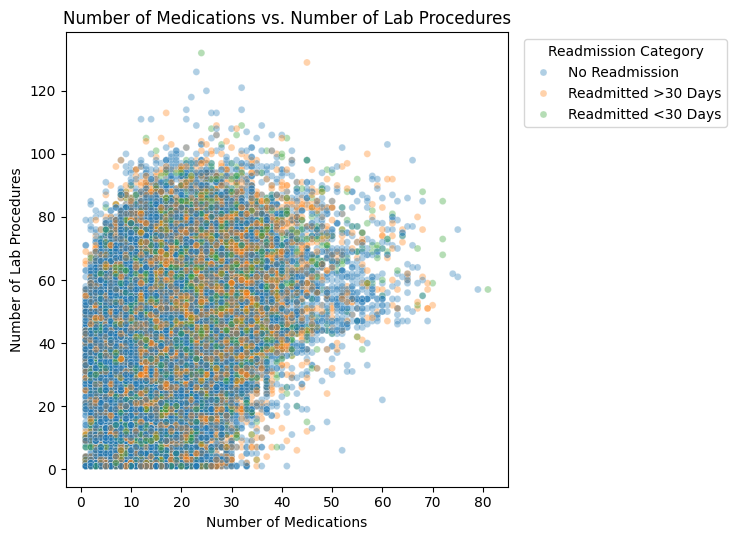

In [59]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.scatterplot(data=df, x="num_medications", y="num_lab_procedures",
                 hue=df["readmitted"].map(readmit_labels), alpha=0.35, s=25, ax=ax)
ax.set_title("Number of Medications vs. Number of Lab Procedures")
ax.set_xlabel("Number of Medications")
ax.set_ylabel("Number of Lab Procedures")
ax.legend(title="Readmission Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Observation**: Age, length of stay, and gender show only modest visual separation across readmission categories, race shows broadly similar readmission profiles across groups, and medications vs. lab procedures shows a diffuse positive relationship with no clear separation by readmission outcome. These visual impressions are tested formally in Section 8.

 ## 3. Multivariate Analysis
### 3.1 Early Readmission Rate by Age and Gender
Combining two demographic factors at once can reveal interactions that are invisible in single-variable comparisons. Here we compute the rate of readmission within 30 days for each age–gender combination.

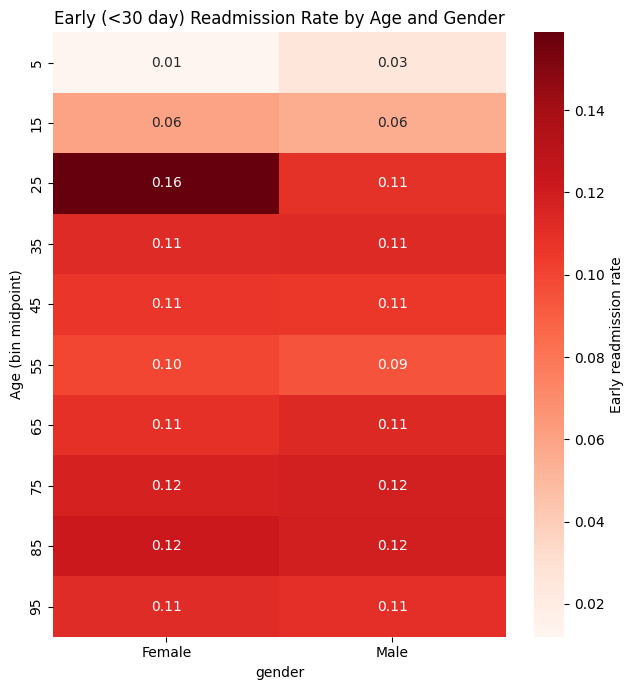

In [60]:
early_readmit_rate = df.pivot_table(
    index="age", columns=df["gender"].map(gender_labels),
    values="readmitted", aggfunc=lambda x: (x == 2).mean()
)

fig, ax = plt.subplots(figsize=(6.5, 7))
sns.heatmap(early_readmit_rate, annot=True, fmt=".2f", cmap="Reds", ax=ax, cbar_kws={"label": "Early readmission rate"})
ax.set_title("Early (<30 day) Readmission Rate by Age and Gender")
ax.set_ylabel("Age (bin midpoint)")
plt.tight_layout()
plt.show()

### 3.2 Joint Distribution of Core Numeric Variables
A pairwise plot of the main utilization variables, colored by readmission status, gives a compact multivariate view of how these variables relate to each other and to the outcome simultaneously. A random sample is used to keep the plot readable.

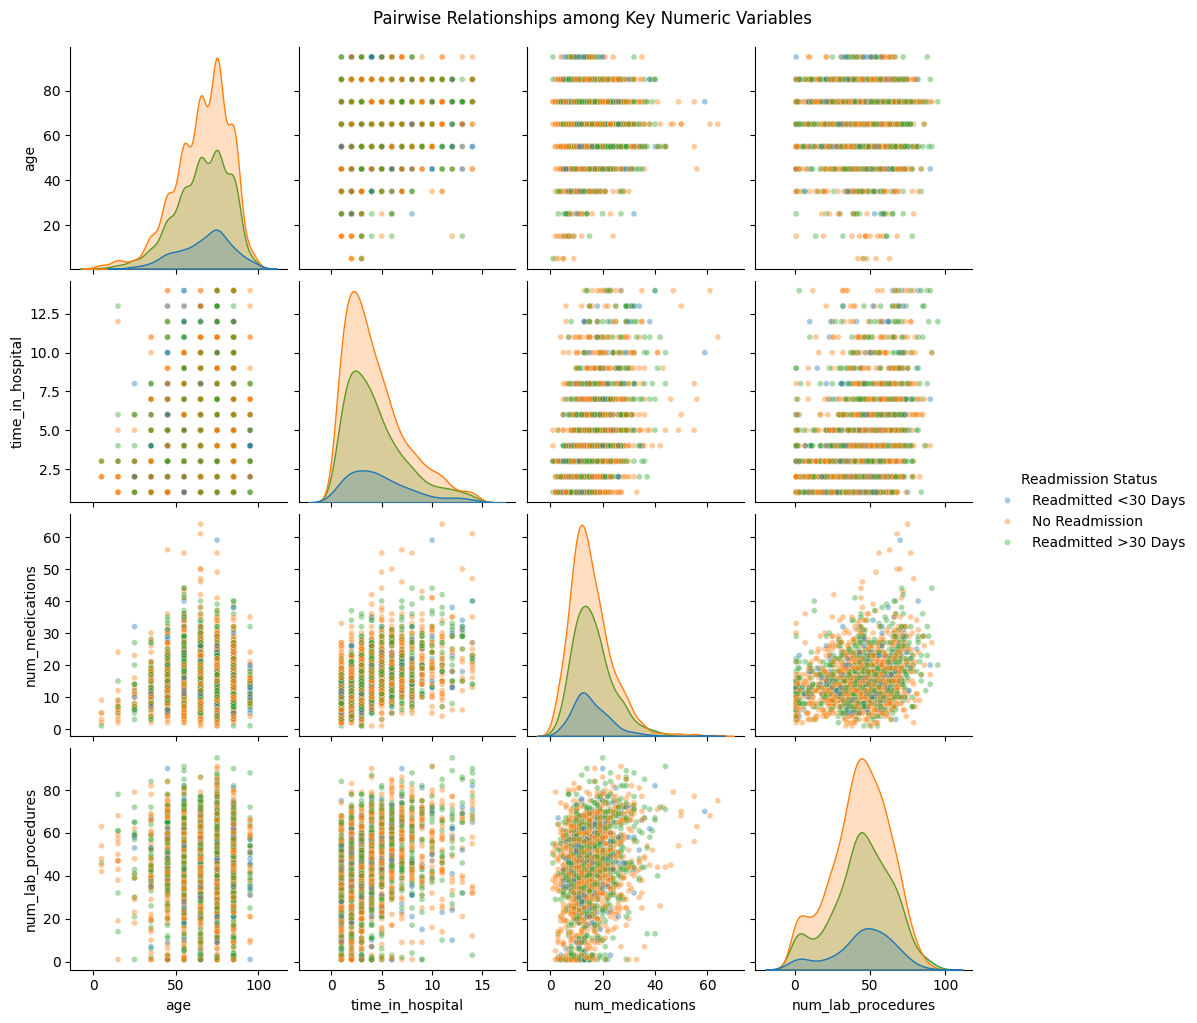

In [61]:
sample_df = df.sample(2000, random_state=42).copy()
sample_df["Readmission Status"] = sample_df["readmitted"].map(readmit_labels)

pairplot_vars = ["age", "time_in_hospital", "num_medications", "num_lab_procedures"]
pp = sns.pairplot(sample_df, vars=pairplot_vars, hue="Readmission Status",
                   diag_kind="kde", plot_kws={"alpha": 0.4, "s": 18})
pp.fig.suptitle("Pairwise Relationships among Key Numeric Variables", y=1.02)
plt.show()

### 3.3 Length of Stay by Admission Type and Readmission Status
This grouped view checks whether the relationship between length of stay and readmission depends on how the patient was admitted.

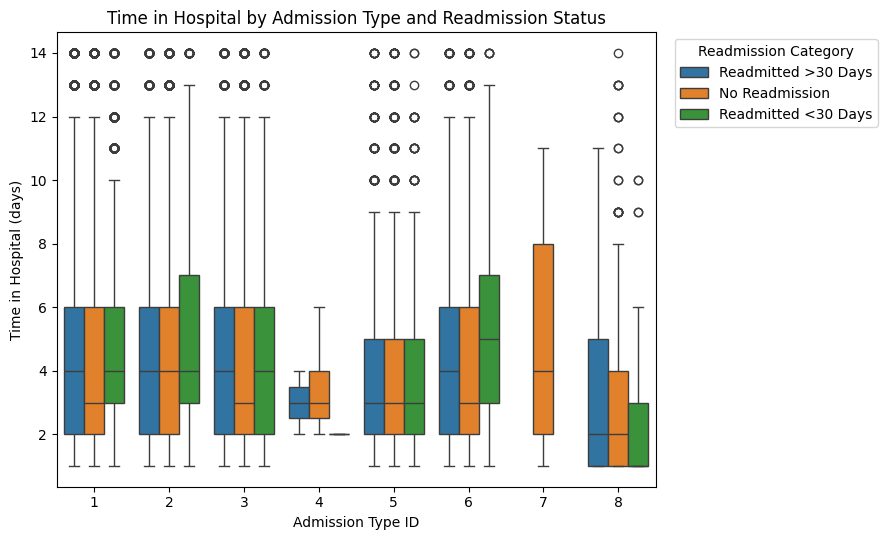

In [62]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=df, x="admission_type_id", y="time_in_hospital",
            hue=df["readmitted"].map(readmit_labels), ax=ax)
ax.set_title("Time in Hospital by Admission Type and Readmission Status")
ax.set_xlabel("Admission Type ID")
ax.set_ylabel("Time in Hospital (days)")
ax.legend(title="Readmission Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Observation**: Early readmission rates stay in a fairly narrow band across age–gender combinations, meaning neither factor alone or in combination is a strong discriminator. The pairwise plot shows the numeric utilization variables are weakly correlated with each other, and length of stay by admission type shows broadly similar medians across readmission groups, reinforcing that no single demographic or utilization variable dominates the readmission outcome — consistent with the statistical tests that follow.

# **4. Statistical Hypothesis Testing**
The sections above (Univariate, Bivariate, Multivariate) are exploratory - they show patterns visually but don't confirm whether those patterns are statistically significant or could simply be due to chance. This section runs formal hypothesis tests to check that.

We use three types of tests depending on the variable types being compared against the target, `readmitted` (0 = No, 1 = >30 days, 2 = <30 days):
- **Chi-square test of independence** - for categorical variable vs. categorical target (e.g., gender, race, diabetesMed).
- **Kruskal-Wallis H-test** - for numeric variable vs. categorical target with 3+ groups. We use this non-parametric test instead of one-way ANOVA because the skewness table above showed several numeric variables (`number_emergency`, `number_outpatient`, `number_inpatient`) are heavily right-skewed, violating ANOVA's normality assumption.
- **Spearman correlation** - for numeric variable vs. numeric variable, since it does not assume linearity or normality either.

An alpha level of **0.05** is used throughout, and effect sizes (Cramer's V, epsilon-squared) are reported alongside p-values so statistical significance can be interpreted together with practical significance.

## **4.1 Chi-Square Test: Categorical Variables vs. Readmission**

In [ ]:
from scipy.stats import chi2_contingency

categorical_vars = ["gender", "race", "diabetesMed", "change", "insulin", "max_glu_serum", "A1Cresult"]

def cramers_v(chi2_stat, contingency_table):
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt((chi2_stat / n) / (min(r - 1, k - 1)))

chi_results = []
for col in categorical_vars:
    contingency = pd.crosstab(df[col], df["readmitted"])
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency)
    v = cramers_v(chi2_stat, contingency)
    chi_results.append({
        "Variable": col,
        "Chi2": round(chi2_stat, 2),
        "dof": dof,
        "p_value": p_val,
        "Cramers_V": round(v, 3),
        "Significant (alpha=0.05)": "Yes" if p_val < 0.05 else "No"
    })

chi_results_df = pd.DataFrame(chi_results).sort_values("p_value")
chi_results_df

**Observation**: A small p-value (< 0.05) means the variable's distribution across readmission categories is unlikely to be due to chance - i.e., the variable is statistically associated with readmission. Cramer's V indicates the strength of that association (roughly: <0.1 negligible, 0.1-0.3 weak, 0.3-0.5 moderate, >0.5 strong). With a dataset this large (~100k rows), even weak associations can be statistically significant, so Cramer's V should be checked alongside the p-value before treating a variable as practically important.

## **4.2 Kruskal-Wallis H-Test: Numeric Variables vs. Readmission**

In [ ]:
from scipy.stats import kruskal

kw_results = []
for col in numeric_cols:
    groups = [df.loc[df["readmitted"] == g, col].dropna() for g in sorted(df["readmitted"].unique())]
    h_stat, p_val = kruskal(*groups)
    n = len(df)
    k = len(groups)
    epsilon_sq = (h_stat - k + 1) / (n - k) if n > k else np.nan  # epsilon-squared effect size
    kw_results.append({
        "Variable": col,
        "H_statistic": round(h_stat, 2),
        "p_value": p_val,
        "Epsilon_squared": round(epsilon_sq, 4),
        "Significant (alpha=0.05)": "Yes" if p_val < 0.05 else "No"
    })

kw_results_df = pd.DataFrame(kw_results).sort_values("p_value")
kw_results_df

**Observation**: Kruskal-Wallis checks whether the median of a numeric variable differs across the three readmission groups. A significant result tells us at least one group differs, but not which ones - that's addressed with a post-hoc test below, run only for variables that came out significant here. Epsilon-squared gives the effect size (same rough interpretation scale as Cramer's V: <0.01 negligible, 0.01-0.06 small, 0.06-0.14 moderate, >0.14 large).

## **4.3 Post-Hoc Pairwise Comparisons (Dunn-style, Bonferroni-corrected)**

In [ ]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from itertools import combinations

sig_numeric_vars = kw_results_df.loc[kw_results_df["p_value"] < 0.05, "Variable"].tolist()
readmit_groups = sorted(df["readmitted"].unique())
pair_labels = {0: "No", 1: ">30 Days", 2: "<30 Days"}

posthoc_rows = []
for col in sig_numeric_vars:
    pvals = []
    pairs = []
    for g1, g2 in combinations(readmit_groups, 2):
        s1 = df.loc[df["readmitted"] == g1, col].dropna()
        s2 = df.loc[df["readmitted"] == g2, col].dropna()
        _, p = mannwhitneyu(s1, s2, alternative="two-sided")
        pairs.append((g1, g2))
        pvals.append(p)
    reject, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method="bonferroni")
    for (g1, g2), p_raw, p_corr, rej in zip(pairs, pvals, pvals_corrected, reject):
        posthoc_rows.append({
            "Variable": col,
            "Group A": pair_labels[g1],
            "Group B": pair_labels[g2],
            "p_value (raw)": p_raw,
            "p_value (Bonferroni)": p_corr,
            "Significant": "Yes" if rej else "No"
        })

posthoc_df = pd.DataFrame(posthoc_rows)
posthoc_df

**Observation**: This narrows down *which specific pair* of readmission groups differs for each numeric variable that was significant overall. Bonferroni correction is applied because running multiple pairwise tests inflates the chance of a false positive, so the corrected p-value is the one that should be used to judge significance here.

## **4.4 Spearman Correlation: Numeric Variables**

In [ ]:
from scipy.stats import spearmanr

corr_matrix = df[numeric_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Spearman Correlation Between Numeric Variables")
plt.tight_layout()
plt.show()

# Significance test for each pair (p-value), flattened into a table
corr_pairs = []
for i, col1 in enumerate(numeric_cols):
    for col2 in numeric_cols[i + 1:]:
        rho, p_val = spearmanr(df[col1], df[col2])
        corr_pairs.append({
            "Variable A": col1,
            "Variable B": col2,
            "Spearman rho": round(rho, 3),
            "p_value": p_val,
            "Significant (alpha=0.05)": "Yes" if p_val < 0.05 else "No"
        })

corr_pairs_df = pd.DataFrame(corr_pairs).sort_values("Spearman rho", key=abs, ascending=False)
corr_pairs_df.head(10)

**Observation**: Spearman's rho ranges from -1 to 1; values near 0 (as seen for most pairs here) confirm what the pairwise plot suggested visually - the numeric utilization variables are largely independent of each other, so multicollinearity is not a major concern if these variables were used together in a predictive model later. Only pairs with both a large |rho| and a significant p-value should be treated as meaningfully correlated.

## **4.5 Summary of Statistical Findings**

- **Chi-square tests** show which categorical variables (gender, race, diabetesMed, change, insulin, lab results) are statistically associated with readmission status, and Cramer's V shows how strong that association actually is.
- **Kruskal-Wallis tests** show which numeric variables (age, time in hospital, utilization counts) differ significantly across the three readmission groups, with epsilon-squared showing effect size.
- **Post-hoc pairwise tests** pinpoint exactly which readmission groups differ for the significant numeric variables.
- **Spearman correlations** confirm the numeric variables are largely independent of one another.

Together, these formal tests confirm the EDA observation above: several variables are *statistically* associated with readmission (given the large sample size, this is expected), but the *effect sizes* are mostly small, meaning no single variable is a strong standalone predictor of readmission - readmission risk is likely driven by a combination of factors rather than any one variable in isolation.